### mini BERT Project

In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

"""
ex14_project.py
Mini BERT pre-training project implementation.
Goal: Vocab Size 8000, Total Parameters ~1M, 10 Epochs.
"""

import os
import re
import gc
import math
import json
import copy
import random
import collections
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import sentencepiece as spm

#### [STEP 0] Setup & Global Config


In [25]:
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Directory setup (Cross-environment: Script & Notebook)
if "__file__" in globals():
    ROOT_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    ROOT_DIR = os.getcwd()

DATA_DIR = os.path.join(ROOT_DIR, "data")
MODELS_DIR = os.path.join(ROOT_DIR, "models")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Path configuration
SPM_PREFIX = os.path.join(MODELS_DIR, "mini_ko_8000")
SPM_MODEL_PATH = f"{SPM_PREFIX}.model"
SPM_VOCAB_PATH = f"{SPM_PREFIX}.vocab"

PRETRAIN_JSON_PATH = os.path.join(DATA_DIR, "bert_pre_train_project.json")
MEMMAP_INFO_PATH = os.path.join(DATA_DIR, "bert_pretrain_memmap_info.json")

FINAL_MODEL_PATH = os.path.join(MODELS_DIR, "mini_bert_final.pt")
HISTORY_PATH = os.path.join(MODELS_DIR, "training_history.json")
PLOT_PATH = os.path.join(MODELS_DIR, "training_curves.png")

# Find kowiki corpus
corpus_file = os.path.join(DATA_DIR, "kowiki.txt")
if not os.path.exists(corpus_file):
    # Try alternate location if not found
    alternate_path = os.path.join(os.getcwd(), "kowiki.txt")
    if os.path.exists(alternate_path):
        corpus_file = alternate_path
    else:
        print(f"WARNING: {corpus_file} not found. Ensure kowiki.txt exists for tokenizer training.")



Using device: cuda
/home/jovyan/work/repo/AIFFEL_quest_eng/NLP/NLP04


#### [STEP 1] SentencePiece Tokenizer


In [3]:
# ============================================================

def setup_tokenizer(corpus_file, vocab_size=8000):
    '''corpus_file -> tokenizer 생성'''
    if not os.path.exists(SPM_MODEL_PATH):
        if not os.path.exists(corpus_file):
            raise FileNotFoundError(f"Corpus file {corpus_file} not found. Cannot train tokenizer.")
        
        # spm으로 tokenizer를 학습
        print("Training SentencePiece model (Vocab Size: 8000)...")
        spm.SentencePieceTrainer.train(
            f"--input={corpus_file} "
            f"--model_prefix={SPM_PREFIX} "
            f"--vocab_size={vocab_size} "
            f"--model_type=bpe "    # BPE Byte Pair Encoding - 가장 빈번한 글자 쌍을 반복적으로 합쳐서 단어 조각 생성
            f"--max_sentence_length=999999 "
            f"--pad_id=0 --pad_piece=[PAD] "
            f"--unk_id=1 --unk_piece=[UNK] "
            f"--bos_id=2 --bos_piece=[BOS] "
            f"--eos_id=3 --eos_piece=[EOS] "
            f"--user_defined_symbols=[SEP],[CLS],[MASK]"
        )
    
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.load(SPM_MODEL_PATH)
    
    # Extract special IDs
    spec_ids = {
        "PAD_ID": tokenizer.piece_to_id("[PAD]"),
        "SEP_ID": tokenizer.piece_to_id("[SEP]"),
        "CLS_ID": tokenizer.piece_to_id("[CLS]"),
        "MASK_ID": tokenizer.piece_to_id("[MASK]")
    }
    
    # Vocab list for random masking (excluding special tokens at the beginning)
    # MLM Masked Language Model 학습 시 (바꿀 후보 단어들) random word 선택 목적
    vocab_list = []
    for idx in range(7, tokenizer.get_piece_size()):
        if not tokenizer.is_unknown(idx):
            vocab_list.append(tokenizer.id_to_piece(idx))
            
    return tokenizer, vocab_list, spec_ids



#### [STEP 2] MLM Masking Logic


In [4]:
# ============================================================

def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    Apply MLM masking: 15% total, 80% [MASK], 10% random, 10% original.
    """
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token in ["[CLS]", "[SEP]"]:
            continue
        # Join words (SentencePiece representation starting with \u2581)
        if 0 < len(cand_idx) and not token.startswith("\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        dice = random.random()
        for index in index_set:
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index] # 10% Keep original
            else:
                masked_token = random.choice(vocab_list) # 10% Random word

            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    return tokens, mask_idx, mask_label



#### [STEP 3] NSP Pair Generation


In [5]:
# ============================================================

def trim_tokens(tokens_a, tokens_b, max_seq):
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

def create_pretrain_instances(tokenizer, doc, n_seq, mask_prob, vocab_list):
    """
    Create NSP pairs: 50% true next, 50% random.
    """
    max_seq = n_seq - 3 # [CLS], [SEP], [SEP]
    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            # 문단 단위로 NSP 학습 데이터를 생성
            a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            # NSP 처리
            if len(current_chunk) == 1 or random.random() < 0.5:
                is_next = 0 # Random
                target_doc_idx = random.randrange(len(doc))
                tokens_b = doc[target_doc_idx].copy()
            else:
                is_next = 1 # Consecutive
                for j in range(a_end, len(current_chunk)):
                    tokens_b.extend(current_chunk[j])

            trim_tokens(tokens_a, tokens_b, max_seq)
            if len(tokens_a) < 1 or len(tokens_b) < 1:
                current_chunk = []
                current_length = 0
                continue

            # 문장 결합
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            
            # MLM 처리
            mask_cnt = max(1, int(round((len(tokens) - 3) * mask_prob)))
            tokens_masked, mask_idx, mask_label = create_pretrain_mask(
                                copy.deepcopy(tokens), mask_cnt, vocab_list)

            instances.append({
                "tokens": tokens_masked,
                "segment": segment,
                "is_next": int(is_next),
                "mask_idx": mask_idx,
                "mask_label": mask_label,
            })
            current_chunk = []
            current_length = 0
            
    return instances

def make_pretrain_data(tokenizer, in_file, out_file, n_seq, vocab_list, mask_prob=0.15):
    '''
    tokenizer -> JSON 형태의 데이터셋(Pre-train data)을 생성
    '''
    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as in_f:
        for _ in in_f: 
            line_cnt += 1

    with open(out_file, "w", encoding="utf-8") as out_f:
        with open(in_file, "r", encoding="utf-8") as in_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt, desc="Generating Pre-train JSON"):
                line = line.strip()
                
                # 빈 줄까지를 한 문단(doc)으로 간주하고 list에 추가. 문장간 관계 학습을 위해 문단 단위로 처리
                if line == "": 
                    if len(doc) > 0:
                        # BERT용 퀴즈(Instance) 정보 생성, 문단 단위로 NSP 학습 데이터 생성,
                        instances = create_pretrain_instances(tokenizer, doc, n_seq, mask_prob, vocab_list)
                        for inst in instances:
                            out_f.write(json.dumps(inst, ensure_ascii=False) + "\n")
                        doc = []
                else:
                    # 문장을 token으로 분할
                    pieces = tokenizer.encode_as_pieces(line)
                    if len(pieces) > 0:
                        doc.append(pieces)
            # 마지막 문단 처리
            if len(doc) > 0:
                instances = create_pretrain_instances(tokenizer, doc, n_seq, mask_prob, vocab_list)
                for inst in instances:
                    out_f.write(json.dumps(inst, ensure_ascii=False) + "\n")



In [6]:
# ============================================================


#### [STEP 4] Dataset Completion (Memmap)


In [7]:
# ============================================================

def build_memmap(tokenizer, json_path, info_path, n_seq, pad_id):
    '''
    JSON 학습 데이터 -> 메모리 맵(Memory Map) 형태의 바이너리 파일로 변환
    {
    "tokens": ["[CLS]", "▁지", "미", ... , "웠다", ".", "[SEP]"], 
    "segment": [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
    "is_next": 0, 
    "mask_idx": [12, 31, 35, 36, 37, 38], 
    "mask_label": ["▁당시", "▁취임", "▁도", "덕", "정", "치를"]
    }

    '''
    with open(json_path, "r", encoding="utf-8") as f:
        total = sum(1 for _ in f)

    # enc_tokens.memmap : 토큰 인덱스 배열, 문장의 단어들을 숫자로 바꾼 것 ([CLS] 사과 [MASK] ... [SEP])
    # segments.memmap : 첫 번째 문장인지(0), 두 번째 문장인지(1) 구분
    # labels_nsp.memmap : NSP 학습 데이터, 1(True) 또는 0(False)
    # labels_mlm.memmap : MLM 학습 데이터, 토큰의 인덱스, [MASK] 자리에 원래 들어있어야 할 진짜 단어의 정답 번호
    enc_path = os.path.join(DATA_DIR, "enc_tokens.memmap")
    seg_path = os.path.join(DATA_DIR, "segments.memmap")
    nsp_path = os.path.join(DATA_DIR, "labels_nsp.memmap")
    mlm_path = os.path.join(DATA_DIR, "labels_mlm.memmap")

    # 메모리 맵(Memory Map) 형태의 바이너리 파일로 변환
    enc_t = np.memmap(enc_path, mode="w+", dtype=np.int32, shape=(total, n_seq))
    seg_t = np.memmap(seg_path, mode="w+", dtype=np.int32, shape=(total, n_seq))
    nsp_l = np.memmap(nsp_path, mode="w+", dtype=np.int32, shape=(total,))
    mlm_l = np.memmap(mlm_path, mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(json_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="Building Memmap")):
            data = json.loads(line)
            # Tokens
            ids = [tokenizer.piece_to_id(p) for p in data["tokens"]]
            ids += [pad_id] * (n_seq - len(ids))
            # Segments
            seg = data["segment"] + [0] * (n_seq - len(data["segment"]))
            # MLM Label
            m_idx = np.array(data["mask_idx"], dtype=np.int32)
            m_lbl = np.array([tokenizer.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, fill_value=pad_id, dtype=np.int32)
            label_mlm[m_idx] = m_lbl

            enc_t[i] = ids
            seg_t[i] = seg
            nsp_l[i] = data["is_next"]
            mlm_l[i] = label_mlm

    enc_t.flush(); seg_t.flush(); nsp_l.flush(); mlm_l.flush()
    
    info = {"total": total, "n_seq": n_seq, "enc_path": enc_path, 
            "seg_path": seg_path, "nsp_path": nsp_path, "mlm_path": mlm_path}
    
    with open(info_path, "w", encoding="utf-8") as f:
        json.dump(info, f, indent=2)
    
    return info

def load_data(info_path, count=None):
    with open(info_path, "r", encoding="utf-8") as f:
        info = json.load(f)
    
    total = info["total"]
    n_seq = info["n_seq"]
    use_count = total if count is None else min(count, total)

    enc = np.array(np.memmap(info["enc_path"], mode="r", dtype=np.int32, shape=(total, n_seq))[:use_count], dtype=np.int64)
    seg = np.array(np.memmap(info["seg_path"], mode="r", dtype=np.int32, shape=(total, n_seq))[:use_count], dtype=np.int64)
    nsp = np.array(np.memmap(info["nsp_path"], mode="r", dtype=np.int32, shape=(total,))[:use_count], dtype=np.int64)
    mlm = np.array(np.memmap(info["mlm_path"], mode="r", dtype=np.int32, shape=(total, n_seq))[:use_count], dtype=np.int64)

    return (enc, seg), (nsp, mlm)



#### [STEP 5] BERT Model Implementation


In [8]:
# ============================================================

class Config(dict):
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

def gelu(x):
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

class BERTEmbeddings(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.tok_embed = nn.Embedding(config.n_vocab, config.d_model)
        self.pos_embed = nn.Embedding(config.n_seq, config.d_model)
        self.seg_embed = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)
        
        nn.init.trunc_normal_(self.tok_embed.weight, std=0.02)
        nn.init.trunc_normal_(self.pos_embed.weight, std=0.02)
        nn.init.trunc_normal_(self.seg_embed.weight, std=0.02)

    def forward(self, input_ids, segment_ids):
        seq_len = input_ids.size(1)
        pos = torch.arange(seq_len, dtype=torch.long, device=input_ids.device).unsqueeze(0)
        
        embed = self.tok_embed(input_ids) + self.pos_embed(pos) + self.seg_embed(segment_ids)
        return self.dropout(self.norm(embed))

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_head = config.n_head
        self.d_head = config.d_model // config.n_head
        self.W_Q = nn.Linear(config.d_model, config.d_model)
        self.W_K = nn.Linear(config.d_model, config.d_model)
        self.W_V = nn.Linear(config.d_model, config.d_model)
        self.linear = nn.Linear(config.d_model, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, Q, K, V, mask):
        bs = Q.size(0)
        q_s = self.W_Q(Q).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        k_s = self.W_K(K).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        v_s = self.W_V(V).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)

        if mask is not None:
            # mask: [bs, seq_len] -> [bs, 1, 1, seq_len]
            mask = mask.unsqueeze(1).unsqueeze(2)
            mask = mask.expand(bs, self.n_head, Q.size(1), K.size(1))

        scores = torch.matmul(q_s, k_s.transpose(-1, -2)) / math.sqrt(self.d_head)
        if mask is not None:
            scores = scores.masked_fill(mask == 1, -1e9)
        
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v_s).transpose(1, 2).contiguous().view(bs, -1, self.n_head * self.d_head)
        return self.dropout(self.linear(out))

class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.mha = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn = nn.Sequential(
            nn.Linear(config.d_model, config.d_ff),
            nn.GELU(),
            nn.Linear(config.d_ff, config.d_model)
        )
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x, mask):
        x = self.norm1(x + self.mha(x, x, x, mask))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x

class MiniBERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embeddings = BERTEmbeddings(config)
        self.encoders = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])
        self.pooler = nn.Linear(config.d_model, config.d_model)
        # MLM head: weight tying with token embeddings
        self.mlm_head = nn.Linear(config.d_model, config.n_vocab, bias=False)
        self.mlm_head.weight = self.embeddings.tok_embed.weight
        self.mlm_bias = nn.Parameter(torch.zeros(config.n_vocab))
        
        self.nsp_head = nn.Linear(config.d_model, 2)
        self.pad_id = config.i_pad

    def forward(self, input_ids, segment_ids):
        mask = (input_ids == self.pad_id).float()
        x = self.embeddings(input_ids, segment_ids)
        for layer in self.encoders:
            x = layer(x, mask)
        
        # MLM
        logits_mlm = self.mlm_head(x) + self.mlm_bias
        # NSP
        cls_token = x[:, 0]
        logits_nsp = self.nsp_head(torch.tanh(self.pooler(cls_token)))
        
        return logits_mlm, logits_nsp



#### [STEP 6] Pre-train Implementation


In [9]:
# ============================================================

def mlm_loss_fn(y_pred, y_true, pad_id):
    loss = F.cross_entropy(
        y_pred.view(-1, y_pred.size(-1)), 
        y_true.view(-1), 
        reduction='none')
    mask = (y_true != pad_id).float().view(-1)
    return (loss * mask).sum() / mask.sum().clamp(min=1.0)

def mlm_acc_fn(y_pred, y_true, pad_id):
    y_pred_class = torch.argmax(y_pred, dim=-1)
    correct = (y_true == y_pred_class).float() * (y_true != pad_id).float()
    return correct.sum() / (y_true != pad_id).float().sum().clamp(min=1.0)

class CosineScheduler:
    def __init__(self, optimizer, total_steps, warmup_steps, base_lr):
        self.optimizer, self.total_steps, self.warmup_steps, self.base_lr = optimizer, total_steps, warmup_steps, base_lr
        self.curr_step = 0
    def step(self):
        self.curr_step += 1
        if self.curr_step < self.warmup_steps:
            lr = self.base_lr * self.curr_step / self.warmup_steps
        else:
            progress = (self.curr_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            lr = 0.5 * self.base_lr * (1 + math.cos(math.pi * progress))
        for group in self.optimizer.param_groups: group['lr'] = lr
        return lr



#### [STEP 7] Visualization


In [10]:
# ============================================================

def plot_history(history):
    epochs = range(1, len(history["total_loss"]) + 1)
    plt.figure(figsize=(6, 4))
    
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history["total_loss"], 'b-', label='Total Loss')
    plt.title('Total Loss')
    plt.grid(True)
    
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history["mlm_acc"], 'g-', label='MLM Acc')
    plt.title('MLM Accuracy')
    plt.grid(True)
    
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history["nsp_acc"], 'r-', label='NSP Acc')
    plt.title('NSP Accuracy')
    plt.grid(True)
    
    plt.subplot(2, 2, 4)
    plt.plot(epochs, history["lr"], 'k-', label='LR')
    plt.title('Learning Rate')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(PLOT_PATH)
    print(f"Training curves saved to {PLOT_PATH}")



Model Parameters: 1,022,530 (Target: ~1,000,000)


Epoch 1/10: 100%|██████████| 2000/2000 [01:22<00:00, 24.36it/s, loss=7.9376, lr=1.00e-04]


[Epoch 01] Loss: 8.5836, MLM Acc: 0.0424, NSP Acc: 0.5801


Epoch 3/10: 100%|██████████| 2000/2000 [01:21<00:00, 24.55it/s, loss=7.4708, lr=8.83e-05]


[Epoch 03] Loss: 7.5981, MLM Acc: 0.0860, NSP Acc: 0.6255


...

[Epoch 08] Loss: 7.1221, MLM Acc: 0.1198, NSP Acc: 0.6791


Epoch 9/10: 100%|██████████| 2000/2000 [01:21<00:00, 24.56it/s, loss=7.0445, lr=3.02e-06]


[Epoch 09] Loss: 7.1058, MLM Acc: 0.1204, NSP Acc: 0.6857


Epoch 10/10: 100%|██████████| 2000/2000 [01:21<00:00, 24.55it/s, loss=7.3091, lr=0.00e+00]


[Epoch 10] Loss: 7.0992, MLM Acc: 0.1206, NSP Acc: 0.6883
Training curves saved to /home/jovyan/work/repo/AIFFEL_quest_eng/NLP/NLP04/models/training_curves.png
Pre-training Complete.


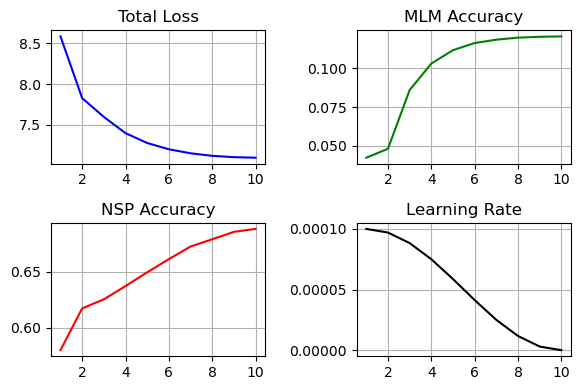

In [26]:
# ============================================================

def main():
    # 1. Tokenizer - SentencePiece
    tokenizer, vocab_list, spec_ids = setup_tokenizer(corpus_file, vocab_size=8000)
    PAD_ID = spec_ids["PAD_ID"]
    
    # 2-4. Data Pipeline : 없으면 준비 ( NSP, MLM, MemoryMap )
    N_SEQ = 128
    if not os.path.exists(PRETRAIN_JSON_PATH):
        make_pretrain_data(tokenizer, corpus_file, PRETRAIN_JSON_PATH, N_SEQ, vocab_list)
    
    if not os.path.exists(MEMMAP_INFO_PATH):
        build_memmap(tokenizer, PRETRAIN_JSON_PATH, MEMMAP_INFO_PATH, N_SEQ, PAD_ID)
    
    # 3. Load Dataset
    limit = 128000          # MAX : None, ??? 어떤 limit 

    # inputs: 모델의 입력값 - 토큰 ID(enc_t), 문장 구분(seg_t) 정보
    # labels: 모델이 맞출 정답 - 다음 문장 예측(nsp_l), 마스크 정답(mlm_l) 정보
    inputs, labels = load_data(MEMMAP_INFO_PATH, count=limit)
    dataset = TensorDataset(     # 
        torch.tensor(inputs[0]), # numpy -> torch.tensor 
        torch.tensor(inputs[1]),
        torch.tensor(labels[0]), 
        torch.tensor(labels[1])
    )
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    # 4. Model Setup (Aiming for ~1M parameters)
    config = Config({
        "d_model": 96,  # 단어의 벡터 차원 수. (BERT-Base는 768)
        "n_head": 4,    # 멀티 헤드 어텐션(Multi-head Attention) 개수. 문장을 4개의 서로 다른 시각으로 분석.
        "d_ff": 192,    # 피드 포워드 네트워크 크기. 보통 d_model의 2~4배로 설정
        "n_layer": 3,   
        "n_vocab": tokenizer.get_piece_size(),  # 단어 사전의 크기. # of Token
        "n_seq": N_SEQ, # 한 번에 입력받는 최대 문장 길이.
        "dropout": 0.1, # 과적합 방지. 
        "layernorm_epsilon": 1e-12, 
        "i_pad": PAD_ID
    })
    
    model = MiniBERT(config).to(device)

    # 모든 Param 개수의 합 
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model Parameters: {total_params:,} (Target: ~1,000,000)")

    # 5. Training Setup
    EPOCHS = 10
    BASE_LR = 1e-4
    total_steps = len(dataloader) * EPOCHS
    optimizer = optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=0.01)
    scheduler = CosineScheduler(optimizer, total_steps, total_steps//10, BASE_LR)
    nsp_loss_fn = nn.CrossEntropyLoss()

    history = {"total_loss": [], "mlm_loss": [], "nsp_loss": [], "mlm_acc": [], "nsp_acc": [], "lr": []}

    # 6. Training Loop
    for epoch in range(1, EPOCHS + 1):
        model.train()
        e_loss, e_mlm_l, e_nsp_l, e_mlm_a, e_nsp_a = 0, 0, 0, 0, 0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}")
        
        for batch in pbar:
            tokens, segs, nsp_lbl, mlm_lbl = [b.to(device) for b in batch]
            
            optimizer.zero_grad()
            out_mlm, out_nsp = model(tokens, segs)
            
            loss_mlm = mlm_loss_fn(out_mlm, mlm_lbl, PAD_ID)
            loss_nsp = nsp_loss_fn(out_nsp, nsp_lbl)
            loss = loss_mlm + loss_nsp
            
            loss.backward()
            optimizer.step()
            curr_lr = scheduler.step()
            
            # Metrics : total, loss, accuracy
            e_loss += loss.item()
            e_mlm_l += loss_mlm.item()
            e_nsp_l += loss_nsp.item()
            with torch.no_grad():
                e_mlm_a += mlm_acc_fn(out_mlm, mlm_lbl, PAD_ID).item()
                e_nsp_a += (torch.argmax(out_nsp, dim=-1) == nsp_lbl).float().mean().item()
            
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{curr_lr:.2e}"})

        # Epoch End
        steps = len(dataloader)
        metrics = {
            "total_loss": e_loss/steps, "mlm_loss": e_mlm_l/steps, "nsp_loss": e_nsp_l/steps,
            "mlm_acc": e_mlm_a/steps, "nsp_acc": e_nsp_a/steps, "lr": curr_lr
        }
        for k, v in metrics.items(): history[k].append(v)
        
        print(f"[Epoch {epoch:02d}] Loss: {metrics['total_loss']:.4f}, "
            f"MLM Acc: {metrics['mlm_acc']:.4f}, NSP Acc: {metrics['nsp_acc']:.4f}")
        
        # Save Checkpoint
        torch.save({"model": model.state_dict(), "history": history}, FINAL_MODEL_PATH)

    # 7. Finalize
    with open(HISTORY_PATH, "w") as f: 
        json.dump(history, f, indent=2)

    plot_history(history)
    print("Pre-training Complete.")

if __name__ == "__main__":
    main()
